# Notebook for torch version of cortical scoreboard model
This is only the spacial scoreboard model, with Polimeni visuotopy

Use the cortex branch of the main p2p repository

torch 2.0

In [1]:
import pulse2percept as p2p
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time
from tqdm.notebook import tqdm

In [2]:
p2p.__version__

'0.9.0.dev0'

<Axes: xlabel='x (mm)', ylabel='y (mm)'>

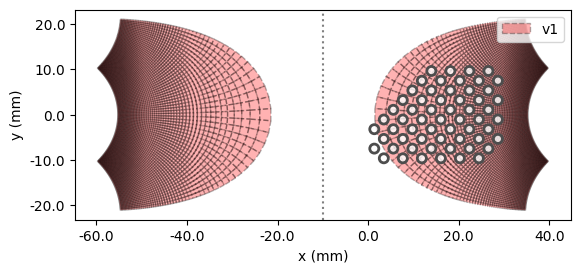

In [3]:
model = p2p.models.cortex.ScoreboardModel(rho=500).build()
implant = p2p.implants.cortex.Orion()
model.plot(style='cell')
implant.plot()

## Torch model
Note that this is a barebones torch implementations. Specifically, it has the following limitaions:

- Only implements v1
- ~~Must be simulating right hemisphere (inverting points in left hemisphere to use right equations not supported yet)~~ Might work now for both
- Just gets v1 locations of visual field cells from p2p model. This means that every time the model is changed in unity, it will have to reinitialize the p2p model and rebuild. 
- Jitter boundary and left_offset features from p2p (to support plotting and both hemispheres) are not implemented

In [4]:
class TorchScoreboardModel(nn.Module):
    def __init__(self, p2pmodel):
        super().__init__()
        if not p2pmodel.is_built:
            p2pmodel.build()
        self.rho = torch.tensor(p2pmodel.rho)
        self.shape = p2pmodel.grid.shape
        self.xV1 = torch.tensor(p2pmodel.grid.v1.x.ravel())
        self.yV1 = torch.tensor(p2pmodel.grid.v1.y.ravel())


    def __call__(self, amps, ex, ey):
        """Predicts the percept
        Parameters
        ----------
        amps, ex, ey : (n_elecs) shaped tensors
            Amplitude, x, and y location (in V1) for each electrode in the implant
        """

        # (npixels, nelecs)
        d2_el = (self.xV1[:, None] - ex[None, :])**2 + (self.yV1[:, None] - ey[None, :])**2
        intensities = amps[None, :] * torch.exp(-d2_el / (2 * self.rho**2))
        intensities = torch.sum(intensities, axis=-1)
        return intensities.reshape(self.shape)

In [5]:
torchmodel = TorchScoreboardModel(model)

<Axes: xlabel='x (degrees of visual angle)', ylabel='y (degrees of visual angle)'>

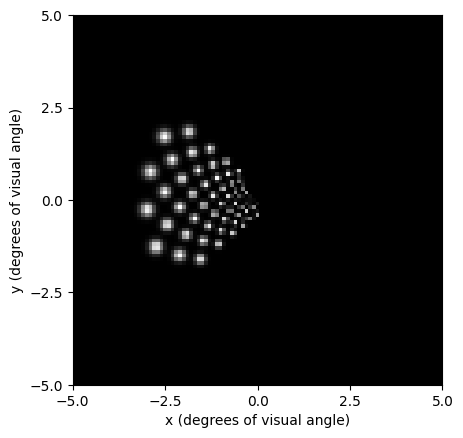

In [6]:
implant.stim = {e : 1 for e in implant.electrodes}
percept_p2p = model.predict_percept(implant)
percept_p2p.plot()

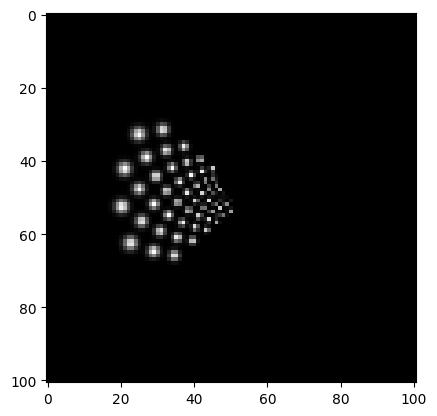

In [7]:
amps = torch.ones(len(implant.stim.electrodes))
ex = torch.tensor([implant.earray[e].x for e in implant.stim.electrodes])
ey = torch.tensor([implant.earray[e].y for e in implant.stim.electrodes])
percept = torchmodel(amps, ex, ey)
plt.imshow(percept.reshape(model.grid.shape), cmap='gray')

In [8]:
maxerror = torch.max(torch.abs(percept.reshape(model.grid.shape) - percept_p2p.data[:, :, 0]))
maxerror

tensor(4.1618e-07, dtype=torch.float64)

In [10]:
%%timeit 
percept = torchmodel(amps, ex, ey) # currently just on shitty laptop cpu

2.69 ms ± 47.6 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [106]:
tmodel = torch.compile(torchmodel) ## cant run without gpu but should make it much faster

## Add Encoder and encoder-model wrapper torch models
TODOs

- Might work for left hemisphere but not sure yet
- Not gpu optimal yet (need to check that some parameters are passed to gpu, and torch.compile)
- Probably good to convolve frame with a gaussian before running, so encoder is not influenced by fine image details

In [160]:
class TorchNaiveEncoder(nn.Module):
    def __init__(self, p2pmodel, amprange=[0, 4]):
        super().__init__()
        if not p2pmodel.is_built:
            p2pmodel.build()
        if (not isinstance(p2pmodel.retinotopy, p2p.topography.Polimeni2006Map) and
            p2pmodel.retinotopy.regions != ['v1']):
            raise ValueError("Must be using Polimeni2006Map with only v1 region")
        
        for param in ['a', 'b', 'k', 'alpha1', 'alpha2', 'alpha3', 'jitter_boundary', 'left_offset']:
            setattr(self, param, torch.tensor(getattr(p2pmodel.retinotopy, param), dtype=torch.float32))
        self.xrange = p2pmodel.xrange
        self.yrange = p2pmodel.yrange
        self.xystep = p2pmodel.xystep
        self.amprange = amprange


    def __call__(self, frame, ex, ey):
        """
        Encodes the frame into a stimulus vector
        Parameters:
        -----------
        frame : (nrows, ncols) shaped tensor
            The frame to encode. Currently this must be the same shape as 
            p2pmode.grid.shape. Would not be hard to change later to allow for different
            shaped frames
        ex, ey : (n_elecs) shaped tensors with x and y locations of each electrode
        """
        ex_dva, ey_dva = self.v1_to_dva(ex, ey)
        # normalize to range [-1, 1]
        ex_dva = ex_dva / (self.xrange[1] - self.xrange[0]) * 2
        ey_dva = ey_dva / (self.yrange[1] - self.yrange[0]) * 2
        # get the pixel values at each electrode
        grid = torch.stack([ex_dva, ey_dva], dim=-1)[None, None, :, :] # (1, 1, nelecs, 2)
        inp_frame = frame[None, None, :, :] # (1, 1, H, W)
        px_brights = torch.nn.functional.grid_sample(inp_frame, grid, padding_mode='border')[..., :]
        amps = (px_brights) * (self.amprange[1] - self.amprange[0]) + self.amprange[0] # might give odd results if frame has negatives
        return amps


    def v1_to_dva(self, x, y):
        """Converts V1 coordinates to degrees of visual angle"""
        x, y, inverted = self._invert_left_cart(x, y, boundary=self.left_offset/2)
        x = x / 1000
        y = y / 1000
        w = x + y*1j
        z = (self.a - self.a * torch.exp(w/self.k)) / (self.a/self.b * torch.exp(w/self.k) - 1)
        t1 = torch.real(z)
        t2 = torch.imag(z)
        r = torch.sqrt(t1**2 + t2**2)
        thetav1 = torch.arctan2(t2, t1)
        theta = thetav1 / self.alpha1
        return self.pol2cart(*self._invert_left_pol(theta, r, ~inverted)[:2])
    

    def pol2cart(self, theta, r):
        """Converts polar coordinates to cartesian coordinates"""
        x = r * torch.cos(theta)
        y = r * torch.sin(theta)
        return x, y
    

    def _invert_left_cart(self, x, y, inverted=None, boundary=0):
        """
        'Corrects' the mapping by flipping x axis if neccesary, allowing for both
         left and right hemisphere to use the same map.
        """
        # Check if we're reverting from an existing inversion
        if inverted is None:
            inverted = x < boundary
            x = torch.where(inverted, -x + self.left_offset, x)
            return x, y, inverted

        # Invert across y axis
        x = torch.where(inverted, -x + self.left_offset, x)
        return x, y, inverted
    
    
    def _invert_left_pol(self, theta, radius, inverted = None):
        """
        'Corrects' the mapping by flipping x axis if necessary, allowing for both
         left and right hemisphere to use the same map.
        """
        # Check if we're reverting from an existing inversion
        if inverted is None:
            inverted = (theta > (np.pi / 2)) | (theta < - (np.pi / 2))

        # Invert theta across y axis
        theta = torch.where(inverted, np.pi - theta, theta)
        theta = torch.where(theta > np.pi, theta - 2*np.pi, theta)
        theta = torch.where(theta <= - np.pi, theta + 2*np.pi, theta)
        
        # Invert theta across x axis
        theta = -theta
        return theta, radius, inverted

In [126]:
class TorchEncoderModel(nn.Module):
    def __init__(self, p2pmodel, implant, amprange=[0, 4]):
        super().__init__()
        self.encoder = TorchNaiveEncoder(p2pmodel, amprange=amprange)
        self.model = TorchScoreboardModel(p2pmodel)
        self.ex = torch.tensor([implant.earray[e].x for e in implant.electrodes], dtype=torch.float32)
        self.ey = torch.tensor([implant.earray[e].y for e in implant.electrodes], dtype=torch.float32)
    
    def __call__(self, frame):
        """
        Encodes the frame into a stimulus vector and predicts the percept
        Parameters:
        -----------
        frame : (nrows, ncols) shaped tensor
            The frame to encode. Currently this must be the same shape as 
            p2pmode.grid.shape. Would not be hard to change later to allow for different
            shaped frames
        
        Returns:
        --------
        percept : p2pmodel.grid.shape shaped tensor
        """
        amps = self.encoder(frame, self.ex, self.ey)
        return self.model(amps, self.ex, self.ey)

### Other tests

In [123]:
# test v1_to_dva
res = []
torchEncoder = TorchNaiveEncoder(model)
for x in np.arange(20000, -20000., -1000):
    for y in np.arange(-20000, 20000., 2000):
        test = torch.tensor(torchEncoder.v1_to_dva(x, y))
        true = torch.tensor(model.retinotopy.v1_to_dva(x, y))
        res.append(torch.abs(test - true))
np.max(res)

y:  -20000.0
y:  -20000.0
y:  -20.0
x:  tensor(20.)
y:  -18000.0
y:  -18000.0
y:  -18.0
x:  tensor(20.)
y:  -16000.0
y:  -16000.0
y:  -16.0
x:  tensor(20.)
y:  -14000.0
y:  -14000.0
y:  -14.0
x:  tensor(20.)
y:  -12000.0
y:  -12000.0
y:  -12.0
x:  tensor(20.)
y:  -10000.0
y:  -10000.0
y:  -10.0
x:  tensor(20.)
y:  -8000.0
y:  -8000.0
y:  -8.0
x:  tensor(20.)
y:  -6000.0
y:  -6000.0
y:  -6.0
x:  tensor(20.)
y:  -4000.0
y:  -4000.0
y:  -4.0
x:  tensor(20.)
y:  -2000.0
y:  -2000.0
y:  -2.0
x:  tensor(20.)
y:  0.0
y:  0.0
y:  0.0
x:  tensor(20.)
y:  2000.0
y:  2000.0
y:  2.0
x:  tensor(20.)
y:  4000.0
y:  4000.0
y:  4.0
x:  tensor(20.)
y:  6000.0
y:  6000.0
y:  6.0
x:  tensor(20.)
y:  8000.0
y:  8000.0
y:  8.0
x:  tensor(20.)
y:  10000.0
y:  10000.0
y:  10.0
x:  tensor(20.)
y:  12000.0
y:  12000.0
y:  12.0
x:  tensor(20.)
y:  14000.0
y:  14000.0
y:  14.0
x:  tensor(20.)
y:  16000.0
y:  16000.0
y:  16.0
x:  tensor(20.)
y:  18000.0
y:  18000.0
y:  18.0
x:  tensor(20.)
y:  -20000.0
y:  -20000

4.5867416699485464e-07

amps tensor([[[[ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
            1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
            1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
            1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
            1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000, -0.0544,
           -0.4024, -0.8685, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
           -1.0000, -1.0000, -1.0000, -1.0000]]]])


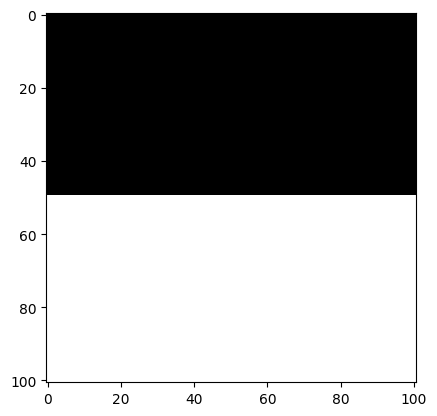

In [159]:
# test just encoder
img = torch.ones(model.grid.shape, dtype=torch.float32)
img[:50, :] = -1
plt.imshow(img, cmap='gray')
ex = torch.tensor([implant.earray[e].x for e in implant.electrodes], dtype=torch.float32)
ey = torch.tensor([implant.earray[e].y for e in implant.electrodes], dtype=torch.float32)
encoder = TorchNaiveEncoder(model, amprange=[0, 1])
amps = encoder(img, ex, ey)
print('amps', amps)

### Test encoder model

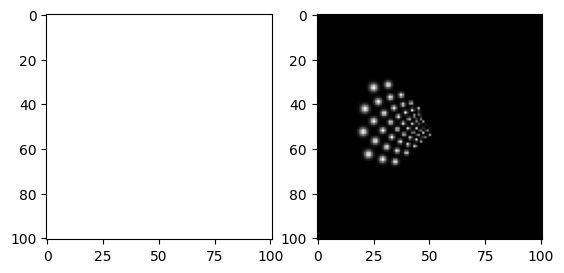

In [168]:
encodermodel = TorchEncoderModel(model, implant, amprange=[0, 1])
img = torch.ones(model.grid.shape)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img, cmap='gray', vmin=0)
percept = encodermodel(img)
axes[1].imshow(percept, cmap='gray')

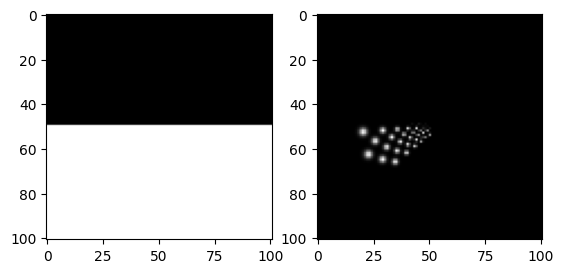

In [169]:
encodermodel = TorchEncoderModel(model, implant, amprange=[0, 1])
img = torch.ones(model.grid.shape)
img[:50] = 0
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img, cmap='gray', vmin=0)
percept = encodermodel(img)
axes[1].imshow(percept, cmap='gray')


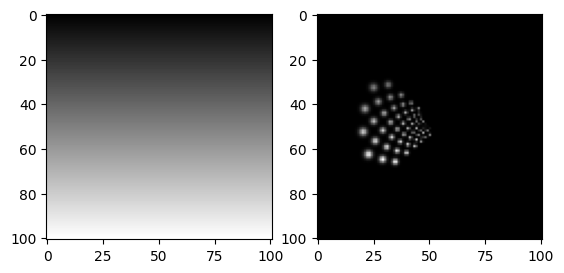

In [166]:
encodermodel = TorchEncoderModel(model, implant, amprange=[0, 1])
img = torch.tensor(torch.meshgrid(torch.arange(0, 101), torch.arange(0, 101))[0], dtype=torch.float32)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(img, cmap='gray')
percept = encodermodel(img)
axes[1].imshow(percept, cmap='gray')

## Make sure theyre the same for all models

In [49]:
# res = []
# for idx in tqdm(range(1000)):
#     implantx = (torch.rand(1) - 0.5) * 2 * 5000 + 15000
#     implanty = (torch.rand(1)-0.5)*2*5000 
#     rho = torch.randint(200, 1000, (1,))
#     xystep = torch.rand(1) * 0.5 + 0.1
#     # print(implantx, implanty, rho, xystep)
#     implant = p2p.implants.cortex.Orion(x=implantx.item(), y=implanty.item())
#     p2pmodel = p2p.models.cortex.ScoreboardModel(xystep=xystep.item(), rho=rho.item())
#     torchmodel = TorchScoreboardModel(p2pmodel)
#     amps = torch.rand(len(implant.electrodes))
#     implant.stim = np.array(amps)
#     ex = torch.tensor([implant.earray[e].x for e in implant.stim.electrodes])
#     ey = torch.tensor([implant.earray[e].y for e in implant.stim.electrodes])

#     perc_p2p = p2pmodel.predict_percept(implant)
#     perc_torch = torchmodel(amps, ex, ey)

#     err = torch.max(torch.abs(torch.tensor(perc_p2p.data[:, :, 0]) - perc_torch))
#     res.append(err)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [50]:
# np.max(res) # always matches

4.216311012217311e-06

## Convert to ONNX

In [107]:
amps = torch.ones(len(implant.stim.electrodes))
ex = torch.tensor([implant.earray[e].x for e in implant.stim.electrodes])
ey = torch.tensor([implant.earray[e].y for e in implant.stim.electrodes])
dummy_input = amps, ex, ey

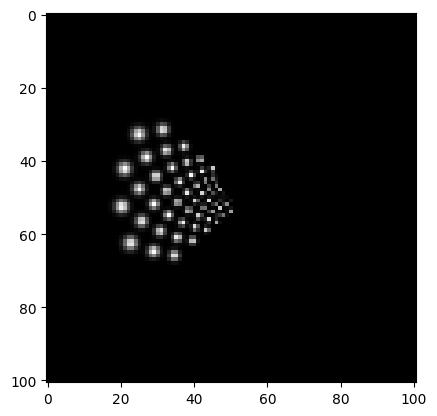

In [108]:
percept = torchmodel(amps, ex, ey)
plt.imshow(percept.reshape(model.grid.shape), cmap='gray')

In [109]:
torch.onnx.export(torchmodel.cuda(), dummy_input, "scoreboard.onnx", verbose=True, input_names=['amp'] + ['ex'] + ['ey'], output_names=['output1'])

Exported graph: graph(%amp : Float(60, strides=[1], requires_grad=0, device=cpu),
      %ex : Double(60, strides=[1], requires_grad=0, device=cpu),
      %ey : Double(60, strides=[1], requires_grad=0, device=cpu)):
  %onnx::Unsqueeze_3 : Long(1, strides=[1], device=cpu) = onnx::Constant[value={0}]() # /tmp/ipykernel_2640/3417615823.py:21:0
  %onnx::Sub_4 : Double(1, 60, strides=[60, 1], requires_grad=0, device=cpu) = onnx::Unsqueeze(%ex, %onnx::Unsqueeze_3) # /tmp/ipykernel_2640/3417615823.py:21:0
  %onnx::Sub_5 : Double(10201, 1, strides=[1, 1], requires_grad=0, device=cpu) = onnx::Constant[value=<Tensor>]() # /tmp/ipykernel_2640/3417615823.py:21:0
  %onnx::Pow_6 : Double(10201, 60, strides=[60, 1], requires_grad=0, device=cpu) = onnx::Sub(%onnx::Sub_5, %onnx::Sub_4) # /tmp/ipykernel_2640/3417615823.py:21:0
  %onnx::Pow_7 : Double(requires_grad=0, device=cpu) = onnx::Constant[value={2}]() # /home/apurv/.local/lib/python3.10/site-packages/torch/_tensor.py:40:0
  %onnx::Add_8 : Double(1

In [110]:
import onnx

# Load the ONNX model
model_onnx = onnx.load("scoreboard.onnx")

# Check that the model is well formed
onnx.checker.check_model(model_onnx)

# Print a human readable representation of the graph
print(onnx.helper.printable_graph(model_onnx.graph))

graph torch_jit (
  %amp[FLOAT, 60]
  %ex[DOUBLE, 60]
  %ey[DOUBLE, 60]
) {
  %onnx::Unsqueeze_3 = Constant[value = <Tensor>]()
  %onnx::Sub_4 = Unsqueeze(%ex, %onnx::Unsqueeze_3)
  %onnx::Sub_5 = Constant[value = <Tensor>]()
  %onnx::Pow_6 = Sub(%onnx::Sub_5, %onnx::Sub_4)
  %onnx::Pow_7 = Constant[value = <Scalar Tensor []>]()
  %onnx::Add_8 = Pow(%onnx::Pow_6, %onnx::Pow_7)
  %onnx::Unsqueeze_9 = Constant[value = <Tensor>]()
  %onnx::Sub_10 = Unsqueeze(%ey, %onnx::Unsqueeze_9)
  %onnx::Sub_11 = Constant[value = <Tensor>]()
  %onnx::Pow_12 = Sub(%onnx::Sub_11, %onnx::Sub_10)
  %onnx::Pow_13 = Constant[value = <Scalar Tensor []>]()
  %onnx::Add_14 = Pow(%onnx::Pow_12, %onnx::Pow_13)
  %onnx::Neg_15 = Add(%onnx::Add_8, %onnx::Add_14)
  %onnx::Unsqueeze_16 = Constant[value = <Tensor>]()
  %onnx::Cast_17 = Unsqueeze(%amp, %onnx::Unsqueeze_16)
  %onnx::Div_18 = Neg(%onnx::Neg_15)
  %onnx::Div_19 = Constant[value = <Scalar Tensor []>]()
  %onnx::Exp_20 = Div(%onnx::Div_18, %onnx::Div_19)
 

In [121]:
import onnxruntime as ort

ort_session = ort.InferenceSession("scoreboard.onnx", providers='CPUExecutionProvider')

EP Error Unknown Provider Type: C when using CPUExecutionProvider
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.


In [124]:
ort_session.get_providers()

['CUDAExecutionProvider', 'CPUExecutionProvider']

In [125]:
%%timeit
outputs = ort_session.run(
    None,
    {'amp': amps.numpy(), 'ex': ex.numpy(), 'ey': ey.numpy()},
)

1.07 ms ± 2.01 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [115]:
outputs[0]

array([[1.27e-112, 9.30e-111, ..., 0.00e+000, 0.00e+000],
       [1.99e-109, 1.65e-107, ..., 0.00e+000, 0.00e+000],
       ...,
       [2.94e-123, 7.60e-122, ..., 0.00e+000, 0.00e+000],
       [5.88e-127, 1.34e-125, ..., 0.00e+000, 0.00e+000]])

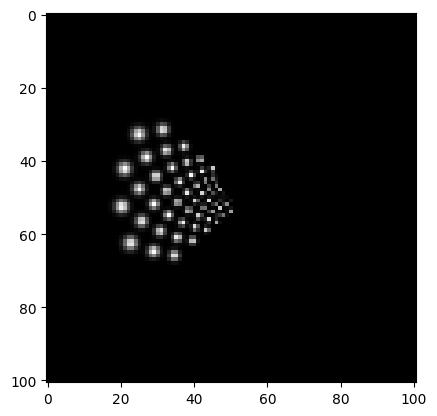

In [126]:
plt.imshow(outputs[0], cmap='gray')